In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


# Bước 1: Đọc dữ liệu (nếu đã chuyển sang CSV)
df = pd.read_csv('seeds_dataset.csv')  
df.head()

,area,perimeter,compactness,length_of_kernel,width_of_kernel,asymmetry_coefficient,length_of_kernel_groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [49]:
# Bước 2: Tách features và labels
X = df.drop('class', axis=1).values
y = df['class'].values
# Kiểm tra kích thước
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique classes:", set(y))

X shape: (210, 7)
y shape: (210,)
Unique classes: {np.int64(1), np.int64(2), np.int64(3)}


In [50]:
# Bước 3: Chia dữ liệu thành tập huấn luyện và tập kiểm tra
# Chia 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 168
Test size: 42


In [51]:
# Bước 4: Tạo và huấn luyện mô hình K-NN
# Khởi tạo mô hình với k = 3
knn = KNeighborsClassifier(n_neighbors=3)

# Huấn luyện
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=3)

In [52]:
# Bước 5: Dự đoán nhãn cho tập test
y_pred = knn.predict(X_test)

# In thử 10 nhãn dự đoán đầu tiên
print("Predictions:", y_pred[:10])


Predictions: [1 3 2 1 3 3 1 3 1 3]


In [53]:
# Bước 6: Tính classification error
# Tính độ chính xác
accuracy = accuracy_score(y_test, y_pred)

# Classification error = 1 - accuracy
error = 1 - accuracy

print(f"Accuracy: {accuracy:.4f}")
print(f"Classification Error: {error:.4f}")


Accuracy: 0.8810
Classification Error: 0.1190


PART3: Vary the value of k

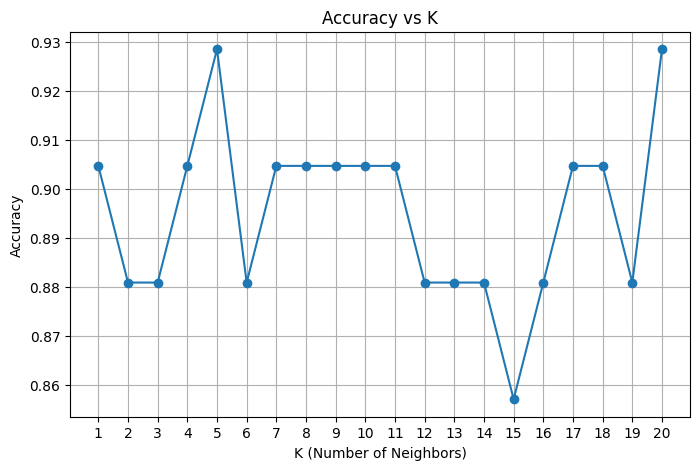

In [54]:
# Chạy nhiều giá trị k
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))  # Tăng kích thước hình
plt.plot(k_values, accuracies, marker='o')
plt.title("Accuracy vs K")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

PART 4: Normalize the input dataset, is the performance better ?

✅ Vì sao cần normalization?
KNN tính khoảng cách (Euclidean)

Nếu các feature có đơn vị khác nhau (ví dụ: cm, mm, %,...) → khoảng cách bị lệch

Normalization giúp các feature đồng đều về thang đo, mô hình hoạt động chính xác hơn

In [55]:
# Bước 1: Chuẩn hóa dữ liệu với StandardScaler
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Kiểm tra kết quả sau chuẩn hóa
print("Mean of each feature (sau chuẩn hóa):", X_scaled.mean(axis=0))
print("Std of each feature (sau chuẩn hóa):", X_scaled.std(axis=0))


Mean of each feature (sau chuẩn hóa): [-3.38353684e-16  1.18423789e-16  1.28574400e-15 -2.09779284e-15
 -3.38353684e-16 -3.38353684e-16 -8.98751972e-17]
Std of each feature (sau chuẩn hóa): [1. 1. 1. 1. 1. 1. 1.]


In [56]:
# Bước 2: Chia lại train/test với dữ liệu đã chuẩn hóa
# Chia tập train/test như cũ
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [57]:
# Bước 3: Huấn luyện lại mô hình KNN (với cùng k = 3)
# KNN với dữ liệu đã chuẩn hóa
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

# Dự đoán
y_pred = knn.predict(X_test_scaled)

# Đánh giá
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy

print(f"Accuracy (after normalization): {accuracy:.4f}")
print(f"Classification Error: {error:.4f}")

Accuracy (after normalization): 0.9048
Classification Error: 0.0952


Nhận xét: 
“Sau khi chuẩn hóa dữ liệu bằng StandardScaler, độ chính xác của mô hình KNN tăng nhẹ từ 88.10% lên 90.48%. Điều này cho thấy chuẩn hóa giúp KNN hoạt động hiệu quả hơn vì các đặc trưng có cùng thang đo, dẫn đến tính toán khoảng cách chính xác hơn.”

PART 5: Apply PCA and SVD

A. Áp dụng PCA

In [ ]:
# from sklearn.decomposition import PCA, TruncatedSVD
# from sklearn.model_selection import train_test_split
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score

# # 1. Áp dụng PCA trên dữ liệu đã chuẩn hóa
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# # 2. Áp dụng SVD trên dữ liệu đã chuẩn hóa
# svd = TruncatedSVD(n_components=2)
# X_svd = svd.fit_transform(X_scaled)

# # 3. Chia train/test (dùng lại cùng cách chia như trước)
# X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)
# X_train_svd, X_test_svd, y_train_svd, y_test_svd = train_test_split(X_svd, y, test_size=0.2, random_state=42)

# # 4. KNN cho PCA
# knn_pca = KNeighborsClassifier(n_neighbors=3)
# knn_pca.fit(X_train_pca, y_train_pca)
# y_pred_pca = knn_pca.predict(X_test_pca)
# acc_pca = accuracy_score(y_test_pca, y_pred_pca)
# err_pca = 1 - acc_pca

# # 5. KNN cho SVD
# knn_svd = KNeighborsClassifier(n_neighbors=3)
# knn_svd.fit(X_train_svd, y_train_svd)
# y_pred_svd = knn_svd.predict(X_test_svd)
# acc_svd = accuracy_score(y_test_svd, y_pred_svd)
# err_svd = 1 - acc_svd

# # 6. In kết quả
# print(f"PCA - Accuracy: {acc_pca:.4f}, Classification Error: {err_pca:.4f}")
# print(f"SVD - Accuracy: {acc_svd:.4f}, Classification Error: {err_svd:.4f}")


PCA - Accuracy: 0.9048, Classification Error: 0.0952
SVD - Accuracy: 0.9048, Classification Error: 0.0952


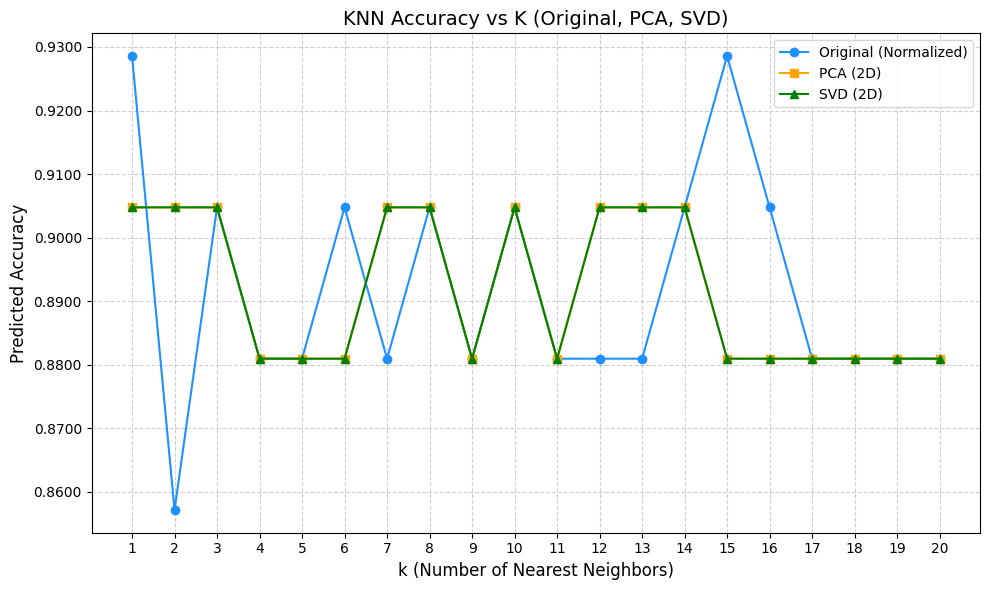

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.ticker as ticker

# Chia train/test cố định để đảm bảo công bằng
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Áp dụng PCA và SVD (2 thành phần)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_full)
X_test_pca = pca.transform(X_test_full)

svd = TruncatedSVD(n_components=2)
X_train_svd = svd.fit_transform(X_train_full)
X_test_svd = svd.transform(X_test_full)

# Danh sách lưu accuracy
acc_orig, acc_pca, acc_svd = [], [], []
k_range = range(1, 21)

# Duyệt qua nhiều k
for k in k_range:
    # Original
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_full, y_train)
    acc_orig.append(accuracy_score(y_test, model.predict(X_test_full)))

    # PCA
    model_pca = KNeighborsClassifier(n_neighbors=k)
    model_pca.fit(X_train_pca, y_train)
    acc_pca.append(accuracy_score(y_test, model_pca.predict(X_test_pca)))

    # SVD
    model_svd = KNeighborsClassifier(n_neighbors=k)
    model_svd.fit(X_train_svd, y_train)
    acc_svd.append(accuracy_score(y_test, model_svd.predict(X_test_svd)))

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(k_range, acc_orig, marker='o', label='Original (Normalized)', color='dodgerblue')
plt.plot(k_range, acc_pca, marker='s', label='PCA (2D)', color='orange')
plt.plot(k_range, acc_svd, marker='^', label='SVD (2D)', color='green')

plt.title("KNN Accuracy vs K (Original, PCA, SVD)", fontsize=14)
plt.xlabel("k (Number of Nearest Neighbors)", fontsize=12)
plt.ylabel("Predicted Accuracy", fontsize=12)
plt.xticks(k_range)
# Định dạng trục Y thành 3 chữ số thập phân (0.881, 0.905,...)
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
